# Lab 1

Multi-Armed Bandit Problem and MDP Foundations

## Part 1

Task: Create a custom multi-armed bandit environment that follows the Gymnasium API structure (implement reset() and step() methods). The bandit should have 10 arms with Gaussian reward distributions. Implement ε-greedy and UCB algorithms as agents using NumPy for numerical computations. Run 2000 time steps across 1000 independent runs. Plot average reward and optimal action percentage over time for each algorithm with multiple parameter settings (try ε ∈ {0.01, 0.1, 0.2} and different UCB confidence levels).

In [57]:
# Loading Libraries
import numpy as np
import matplotlib.pyplot as plt


### Creating the Custom Environment that follows the Gymnasium API Structure

In [58]:
class GaussianBanditEnv:

    def __init__(self, k=10):
        self.k = k

    def reset(self):

        self.q_true = np.random.normal(0, 1, self.k) # Initializing the true action values from N(0,1)


        self.optimal_action = np.argmax(self.q_true) # Identifying the optimal arm

        return None

    def step(self, action):

        reward = np.random.normal(self.q_true[action], 1) # Generating the rewards from the Gaussian distribution centered at true value

        terminated = False
        truncated = False

        return None, reward, terminated, truncated, {}

### Setting up Agents for the task

#### ε-Greedy Agent

In [59]:
def epsilon_greedy(env, epsilon, steps):

    k = env.k # Setting up environment

    Q = np.zeros(k) # Initializing the action value as 0
    N = np.zeros(k) # Initializing the number of times action is selected at 0

    rewards = np.zeros(steps) # Initializing the rewards at 0
    optimal = np.zeros(steps) # Initializing the optimal action taken at 0

    for t in range(steps): # Looping over the number of steps

        if np.random.rand() < epsilon:
            action = np.random.randint(k)
        else:
            action = np.argmax(Q)

        _, reward, _, _, _ = env.step(action)

        N[action] += 1

        Q[action] += (reward - Q[action]) / N[action] # Computing Reward

        rewards[t] = reward

        if action == env.optimal_action:
            optimal[t] = 1 # Computing Optimal Action

    return rewards, optimal

#### UCB Agent

In [60]:
def ucb_agent(env, c, steps):

    k = env.k # Setting up environment

    Q = np.zeros(k) # Initializing the action value as 0
    N = np.zeros(k) # Initializing the number of times action is selected at 0

    rewards = np.zeros(steps) # Initializing the rewards at 0
    optimal = np.zeros(steps) # Initializing the optimal action taken at 0

    for t in range(steps): # Looping over the number of steps

        if t < k: # Introducing condition that tries all arms initially before selection
            action = t
        else:
            ucb_values = Q + c * np.sqrt(np.log(t + 1) / (N + 1e-5)) # Using UCB formula with small constant added to N
            action = np.argmax(ucb_values)

        _, reward, _, _, _ = env.step(action)

        N[action] += 1

        Q[action] += (reward - Q[action]) / N[action] # Computing Reward

        rewards[t] = reward

        if action == env.optimal_action:
            optimal[t] = 1 # Computing Optimal Action

    return rewards, optimal

### Setting up the MAB Experiement

In [61]:
runs = 1000 # Initializing the total number of indepndent runs
steps = 2000 # Initializing the number of steps in each run

epsilons = [0.01, 0.1, 0.2] # Set of epsilon paramter values for ε-Greedy agent
ucb_cs = [0.5, 1, 2] # Set of confidence interval values for UCB agent

env = GaussianBanditEnv(k=10) # Setting the number of arms at k=10

#### ε-Greedy Experiments

In [62]:
epsilon_results_reward = {} # Initializing storage for rewards
epsilon_results_optimal = {} # Initializing storage for optimal actions

for eps in epsilons: # Looping over the set of epsilon parameter values

    rewards = np.zeros((runs, steps)) # Initializing the rewards to 0 for each run-step combination
    optimal = np.zeros((runs, steps)) # Initializing the optimal actions to 0 for each run-step combination

    for r in range(runs): # Looping over independent runs

        env.reset() # Reseting environment

        rwd, opt = epsilon_greedy(env, eps, steps) # Implementing ε-Greedy agent algorithm

        rewards[r] = rwd # Storing rewards
        optimal[r] = opt # Storing optimal action

    epsilon_results_reward[eps] = rewards.mean(axis=0) # Getting average rewards
    epsilon_results_optimal[eps] = optimal.mean(axis=0) # Getting average optimal action


#### UCB Experiments

In [63]:
ucb_results_reward = {} # Initializing storage for rewards
ucb_results_optimal = {} # Initializing storage for optimal actions

for c in ucb_cs: # Looping over the set of c parameter values

    rewards = np.zeros((runs, steps)) # Initializing the rewards to 0 for each run-step combination
    optimal = np.zeros((runs, steps)) # Initializing the optimal actions to 0 for each run-step combination

    for r in range(runs): # Looping over independent runs

        env.reset() # Reseting environment

        rwd, opt = ucb_agent(env, c, steps) # Implementing UCB agent algorithm

        rewards[r] = rwd # Storing rewards
        optimal[r] = opt # Storing optimal action

    ucb_results_reward[c] = rewards.mean(axis=0) # Getting average rewards
    ucb_results_optimal[c] = optimal.mean(axis=0) # Getting average optimal action


### Rewards Comparisons

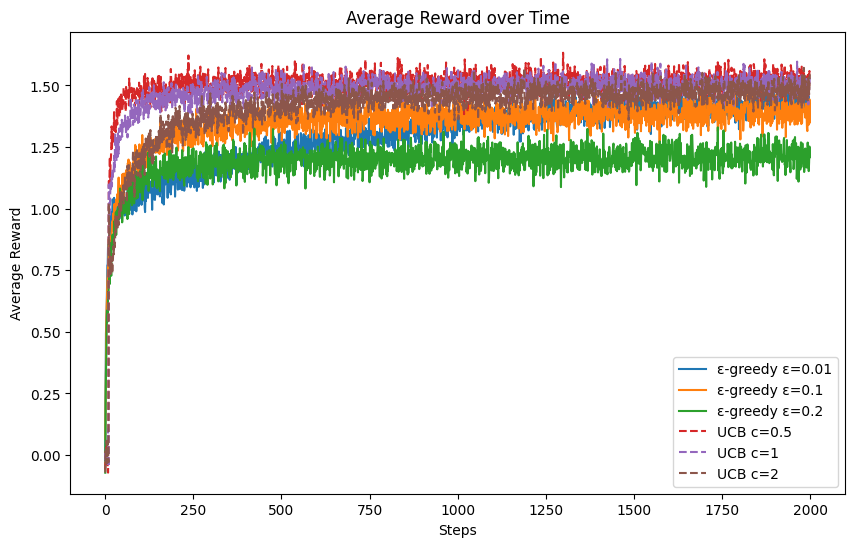

In [64]:
plt.figure(figsize=(10,6))

for eps in epsilons: # Looping to plot rewards for each epslion value for the ε-Greedy agent
    plt.plot(epsilon_results_reward[eps], label=f"ε-greedy ε={eps}")

for c in ucb_cs: # Looping to plot rewards for each c value for the UCB agent
    plt.plot(ucb_results_reward[c], linestyle='--', label=f"UCB c={c}")

plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward over Time")
plt.legend()
plt.show()


### Optimal Action Comparisons

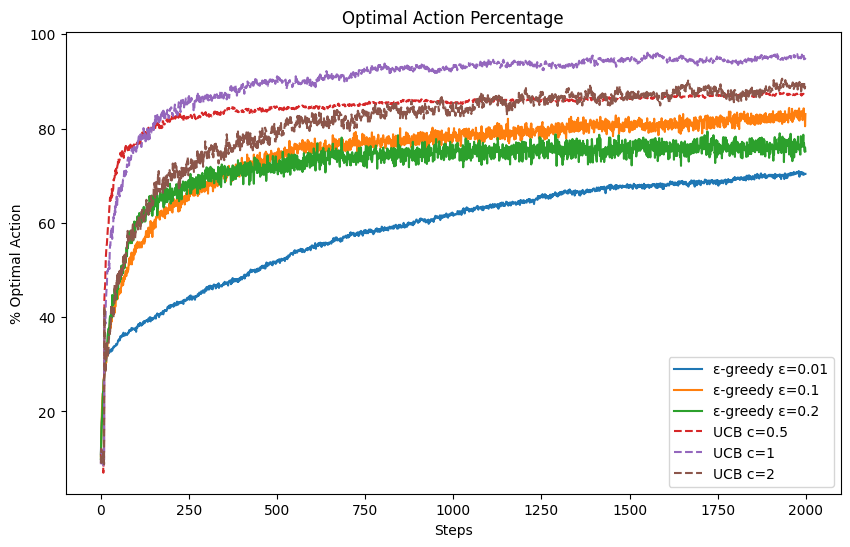

In [65]:
plt.figure(figsize=(10,6))

for eps in epsilons: # Looping to plot rewards for each epslion value for the ε-Greedy agent
    plt.plot(epsilon_results_optimal[eps] * 100, label=f"ε-greedy ε={eps}")

for c in ucb_cs: # Looping to plot rewards for each c value for the UCB agent
    plt.plot(ucb_results_optimal[c] * 100, linestyle='--', label=f"UCB c={c}")

plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Percentage")
plt.legend()
plt.show()


## Part 2

Task: Explore Gymnasium’s standard environments (FrozenLake-v1, Taxi-v3). Write code to inspect their observation and action spaces (discrete vs. continuous, dimensions, bounds). Implement a random policy agent and measure its performance. Document how the MDP tuple (S, A, R, P, γ) maps to Gymnasium’s API. Your implementation should be modular with separate agent classes that interact with environments through the standard interface.

In [66]:
# Installing gymnasium
%pip install gymnasium

In [67]:
# Libraries
import gymnasium as gym
import numpy as np

### Environment Inspection Function

In [68]:
def inspect_environment(env_name):

    env = gym.make(env_name) # Getting environment from Gymnasium API
    print("__________________________")
    print(f"\nEnvironment: {env_name}") # Printing environment name


    obs_space = env.observation_space # Getting State Space for environment
    act_space = env.action_space # Getting Action Space for environment

    print("Observation Space:", obs_space)  # Printing State Space for environment
    print("Action Space:", act_space) # Printing Action Space for environment

    # Inspecting space details
    if isinstance(obs_space, gym.spaces.Discrete):
        print("Observation Type: Discrete")
        print("Number of states:", obs_space.n)

    elif isinstance(obs_space, gym.spaces.Box):
        print("Observation Type: Continuous")
        print("Shape:", obs_space.shape)
        print("Bounds:", obs_space.low, obs_space.high)

    # Getting Action space details
    if isinstance(act_space, gym.spaces.Discrete):
        print("Action Type: Discrete")
        print("Number of actions:", act_space.n)

    elif isinstance(act_space, gym.spaces.Box):
        print("Action Type: Continuous")
        print("Shape:", act_space.shape)
        print("Bounds:", act_space.low, act_space.high)

    env.close()


### Applying Inspection Function to FrozenLake and Taxi Environments

In [69]:
inspect_environment("FrozenLake-v1") # Inspecting the Frozen Lake-v1 environment
inspect_environment("Taxi-v3") # Inspecting the Taxi-v3 environment

__________________________

Environment: FrozenLake-v1
Observation Space: Discrete(16)
Action Space: Discrete(4)
Observation Type: Discrete
Number of states: 16
Action Type: Discrete
Number of actions: 4
__________________________

Environment: Taxi-v3
Observation Space: Discrete(500)
Action Space: Discrete(6)
Observation Type: Discrete
Number of states: 500
Action Type: Discrete
Number of actions: 6


### Agents' Set-up

#### Standard Interface Class

In [70]:
class Agent: #Setting up standard interface class

    def __init__(self, action_space):
        self.action_space = action_space

    def select_action(self, state):
        raise NotImplementedError

#### Random Policy Agent

In [71]:
class RandomAgent(Agent): # Setting up random policy agent

    def __init__(self, action_space):
        super().__init__(action_space)

    def select_action(self, state):
        return self.action_space.sample()

### Episode Function for a Single Run

In [72]:
def run_episode(env, agent, max_steps=1000): # Setting 1000 steps for the episodes

    state, _ = env.reset() # Resetting environment

    total_reward = 0 # Initializing the total rewards at 0.

    for step in range(max_steps): # Looping over the steps

        action = agent.select_action(state)

        next_state, reward, terminated, truncated, _ = env.step(action)

        total_reward += reward # Computing total reward

        state = next_state

        if terminated or truncated:
            break

    return total_reward


### Agent Performance Function

In [73]:
def evaluate_agent(env_name, agent_class, episodes=1000, seed=None):

    env = gym.make(env_name) # Setting up the environment

    if seed is not None: # Initializing seed
        np.random.seed(seed)
        env.action_space.seed(seed)

    agent = agent_class(env.action_space) # Implementing the Random Policy agent algorithm

    rewards = [] # setting up storage for rewards

    for ep in range(episodes): # Looping over episodes

        if seed is not None: # Initializing seed
            state, _ = env.reset(seed=seed + ep)
        else:
            state, _ = env.reset()

        episode_reward = run_episode(env, agent) # Getting total rewards per episode

        rewards.append(episode_reward) # Getting rewards value

    env.close()

    avg_reward = np.mean(rewards) # Getting average rewards value

    print(f"\nEnvironment: {env_name}") # Printing environment name
    print(f"Episodes: {episodes}") # Printing Number of episodes
    print(f"Average Reward: {avg_reward:.3f}") # Printingaverage rewards value

    return rewards

### Agent Performance Evaluation

In [75]:
evaluate_agent("FrozenLake-v1", RandomAgent, episodes=1000, seed = 1)
evaluate_agent("Taxi-v3", RandomAgent, episodes=1000, seed = 1)


Environment: FrozenLake-v1
Episodes: 1000
Average Reward: 0.011

Environment: Taxi-v3
Episodes: 1000
Average Reward: -769.133


[-821,
 -830,
 -767,
 -668,
 -821,
 -767,
 -866,
 -920,
 -893,
 -731,
 -740,
 -803,
 -794,
 -704,
 -776,
 -794,
 -785,
 -767,
 -812,
 -830,
 -659,
 -857,
 -794,
 -758,
 -668,
 -956,
 -749,
 -803,
 -794,
 -740,
 -965,
 -650,
 -749,
 -821,
 -794,
 -857,
 -803,
 -650,
 -776,
 -821,
 -821,
 -884,
 -11,
 -776,
 -839,
 -803,
 -821,
 -604,
 -758,
 -794,
 -848,
 -713,
 -911,
 -821,
 -830,
 -686,
 -803,
 -803,
 -614,
 -857,
 -803,
 -821,
 -767,
 -848,
 -785,
 -812,
 -884,
 -641,
 -812,
 -740,
 -427,
 -659,
 -812,
 -839,
 -695,
 -785,
 -812,
 -803,
 -740,
 -821,
 -749,
 -920,
 -830,
 -902,
 -785,
 -848,
 -686,
 -785,
 -812,
 -794,
 -857,
 -929,
 -677,
 -794,
 -812,
 -776,
 -821,
 -749,
 -740,
 -767,
 -704,
 -722,
 -857,
 -749,
 -740,
 -803,
 -812,
 -857,
 -745,
 -758,
 -794,
 -731,
 -668,
 -740,
 -830,
 -749,
 -821,
 -893,
 -749,
 -821,
 -677,
 -821,
 -749,
 -812,
 -623,
 -776,
 -758,
 -866,
 -929,
 -722,
 -713,
 -659,
 -821,
 -839,
 -839,
 -749,
 -758,
 -830,
 -713,
 -767,
 -722,
 -731,
 -776,
